In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

experiment_dir = Path("../experiment")
figures_dir = Path("../img/experiments_viz")

In [3]:
df_run_metrics = pd.read_csv(experiment_dir / "run_metrics.csv")
df_run_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   scenario              50 non-null     int64  
 1   run                   50 non-null     int64  
 2   seed                  50 non-null     int64  
 3   generated_trucks      50 non-null     int64  
 4   completed_trucks      50 non-null     int64  
 5   completion_rate       50 non-null     float64
 6   p95_travel_time       50 non-null     float64
 7   broken_bridges_count  50 non-null     int64  
 8   broken_A              50 non-null     int64  
 9   broken_B              50 non-null     int64  
 10  broken_C              50 non-null     int64  
 11  broken_D              50 non-null     int64  
 12  mean_delay_per_truck  50 non-null     float64
dtypes: float64(3), int64(10)
memory usage: 5.2 KB


In [4]:
df_all_scenarios = pd.read_csv(experiment_dir / "all_scenarios.csv")
df_all_scenarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1232985 entries, 0 to 1232984
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   vehicle_id            1232985 non-null  object 
 1   generated_at_step     1232985 non-null  int64  
 2   removed_at_step       1232985 non-null  int64  
 3   travel_time_min       1232985 non-null  int64  
 4   total_delay_time_min  1232985 non-null  float64
 5   generated_by          1232985 non-null  object 
 6   scenario              1232985 non-null  int64  
 7   run                   1232985 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 75.3+ MB


<Figure size 1000x600 with 0 Axes>

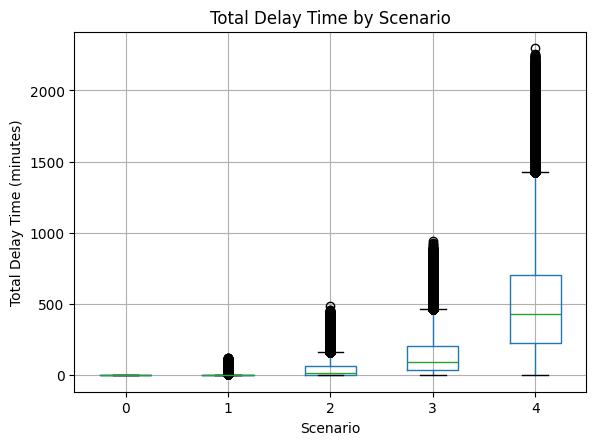

In [5]:
# Boxplot of total_delay_time by scenario
plt.figure(figsize=(10, 6))
df_all_scenarios.boxplot(column="total_delay_time_min", by="scenario")
plt.title("Total Delay Time by Scenario")
plt.suptitle("")
plt.xlabel("Scenario")
plt.ylabel("Total Delay Time (minutes)")
plt.savefig(figures_dir / "total_delay_time_by_scenario.png")
plt.show()

<Figure size 1000x600 with 0 Axes>

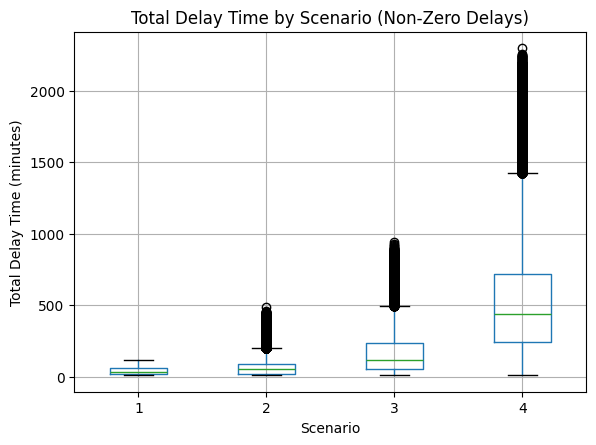

In [6]:
# Boxplot of total_delay_time_min by scenario only non-zero delays
plt.figure(figsize=(10, 6))
df_all_scenarios_non_zero = df_all_scenarios[df_all_scenarios["total_delay_time_min"] > 0]
df_all_scenarios_non_zero.boxplot(column="total_delay_time_min", by="scenario")
plt.title("Total Delay Time by Scenario (Non-Zero Delays)")
plt.suptitle("")
plt.xlabel("Scenario")
plt.ylabel("Total Delay Time (minutes)")
plt.savefig(figures_dir / "total_delay_time_by_scenario_non_zero.png")
plt.show()

<Figure size 1000x600 with 0 Axes>

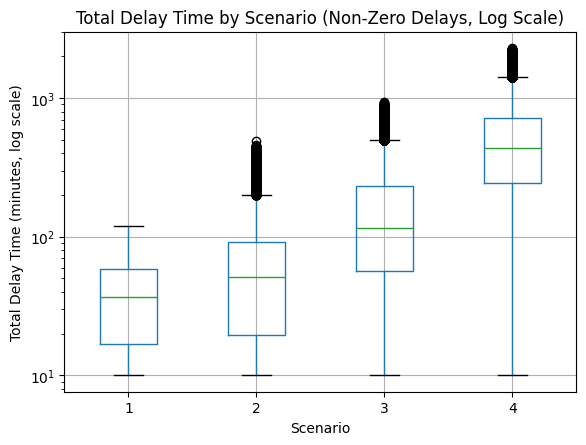

In [7]:
# Boxplot of total_delay_time_min by scenario on log y scale only non-zero delays
plt.figure(figsize=(10, 6))
df_all_scenarios_non_zero.boxplot(column="total_delay_time_min", by="scenario")
plt.yscale("log")
plt.title("Total Delay Time by Scenario (Non-Zero Delays, Log Scale)")
plt.suptitle("")
plt.xlabel("Scenario")
plt.ylabel("Total Delay Time (minutes, log scale)")
plt.savefig(figures_dir / "total_delay_time_by_scenario_non_zero_log_scale.png")
plt.show()

<Figure size 1000x600 with 0 Axes>

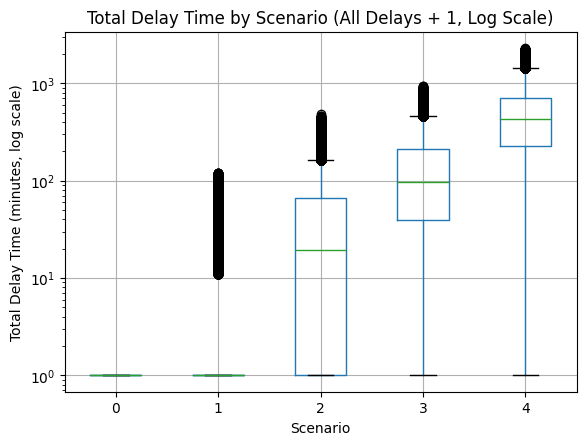

In [8]:
# Boxplot of total_delay_time_min by scenario log scale all delay + 1
plt.figure(figsize=(10, 6))
df_all_scenarios["total_delay_time_min_log"] = df_all_scenarios["total_delay_time_min"] + 1
df_all_scenarios.boxplot(column="total_delay_time_min_log", by="scenario")
plt.yscale("log")
plt.title("Total Delay Time by Scenario (All Delays + 1, Log Scale)")
plt.suptitle("")
plt.xlabel("Scenario")
plt.ylabel("Total Delay Time (minutes, log scale)")
plt.savefig(figures_dir / "total_delay_time_by_scenario_one_log_scale.png")
plt.show()

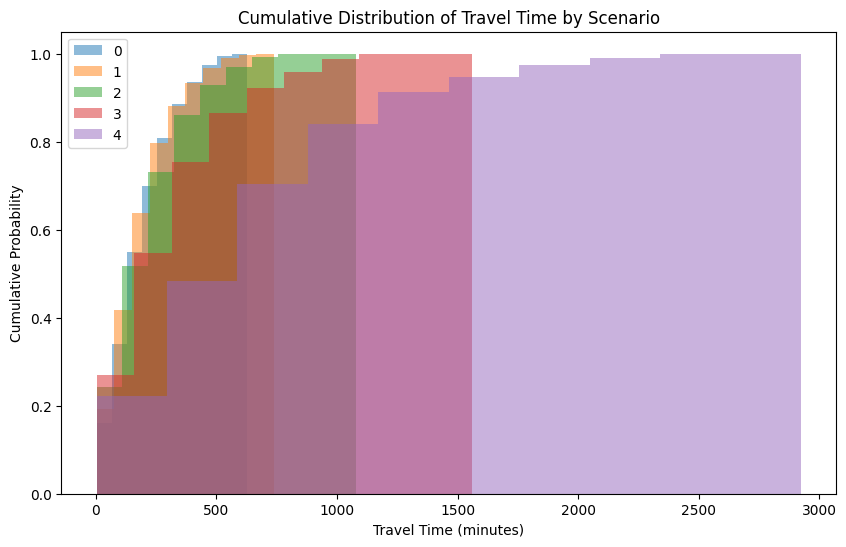

In [9]:
# Plot cumulative distribution of travel_time_min by scenario
plt.figure(figsize=(10, 6))
for scenario in df_all_scenarios["scenario"].unique():
    subset = df_all_scenarios[df_all_scenarios["scenario"] == scenario]
    subset["travel_time_min"].plot(kind="hist", cumulative=True, density=True, label=scenario, alpha=0.5)   
plt.title("Cumulative Distribution of Travel Time by Scenario")
plt.xlabel("Travel Time (minutes)")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.savefig(figures_dir / "cumulative_distribution_travel_time_by_scenario.png")
plt.show()

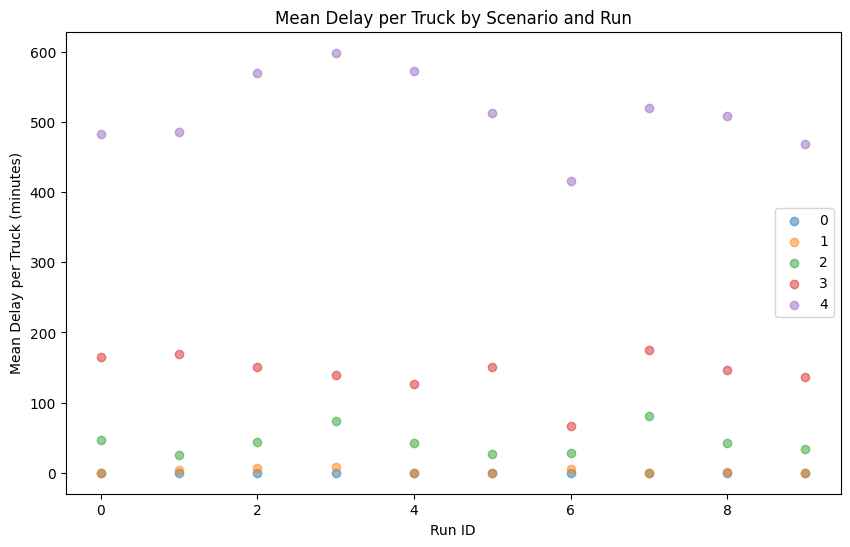

In [10]:
# Uncertainty analysis: run-level dot plot of mean_delay_per_truck by scenario
plt.figure(figsize=(10, 6))
for scenario in df_run_metrics["scenario"].unique():
    subset = df_run_metrics[df_run_metrics["scenario"] == scenario]
    plt.scatter(subset["run"], subset["mean_delay_per_truck"], label=scenario, alpha=0.5)
plt.title("Mean Delay per Truck by Scenario and Run")
plt.xlabel("Run ID")
plt.ylabel("Mean Delay per Truck (minutes)")
plt.legend()
plt.savefig(figures_dir / "mean_delay_per_truck_by_scenario_and_run.png")
plt.show()

<Figure size 1000x600 with 0 Axes>

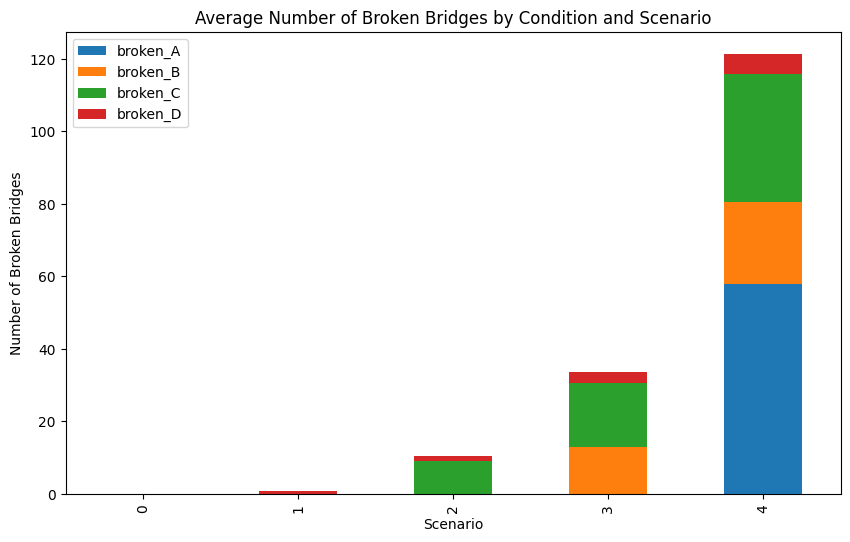

In [14]:
# Plot stacked bar chart of broken bridges by condition (broken_A - broken_D) and scenario
plt.figure(figsize=(10, 6))
bridge_conditions = ["broken_A", "broken_B", "broken_C", "broken_D"]

df_plot = df_run_metrics.groupby("scenario")[bridge_conditions].mean()

ax = df_plot.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Average Number of Broken Bridges by Condition and Scenario")
plt.xlabel("Scenario")
plt.ylabel("Number of Broken Bridges")
plt.legend()
plt.savefig(figures_dir / "broken_bridges_by_condition_and_scenario.png")
plt.show()

In [12]:
# Create summary_table of metrics by scenario
summary_table = df_run_metrics.groupby("scenario").agg(
    completion_rate=("completion_rate", "mean"),
    p95_travel_time=("p95_travel_time", "mean"),
    mean_delay_per_truck=("mean_delay_per_truck", "mean"),
    broken_bridges_count=("broken_bridges_count", "mean"))
summary_table.head()

summary_table_add = df_all_scenarios.groupby("scenario").agg(
    mean_travel_time_min=("travel_time_min", "mean"),
    median_travel_time_min=("travel_time_min", "median"))

summary_table = summary_table.join(summary_table_add)
order = ["completion_rate", "mean_travel_time_min", "median_travel_time_min", "p95_travel_time", "mean_delay_per_truck", "broken_bridges_count"]
summary_table = summary_table[order]
summary_table.head()


,completion_rate,mean_travel_time_min,median_travel_time_min,p95_travel_time,mean_delay_per_truck,broken_bridges_count
scenario,,,,,,
0,0.972130,200.199150,175.0,466.800,0.000000,0.0
1,0.971644,202.702382,175.0,483.100,2.613309,0.7
2,0.966011,244.092232,212.0,593.585,44.457693,10.5
3,0.951671,340.440518,284.0,904.720,142.524691,33.7
4,0.895432,706.065370,605.0,1801.670,513.867843,121.4


In [13]:
# Most affected sources 
most_affected_sources = df_all_scenarios.groupby("generated_by")["total_delay_time_min"].mean().sort_values(ascending=False).head(5)
display(most_affected_sources)

generated_by
SourceSink1001960    348.779412
SourceSink1002913    196.379319
SourceSink1004261    161.833225
SourceSink1004894    144.531623
SourceSink1002599    138.511807
Name: total_delay_time_min, dtype: float64